# 单因子分析 - 动量因子 (mom_20d)

这个 notebook 按一套标准的单因子研究流程，回答 4 个问题：

1. 因子有没有被正确构造和清洗。
2. 因子对未来收益有没有横截面预测力。
3. 信号是否足够稳定，值得继续研究。
4. 如果把 Q5 高分组做成轻量组合，扣掉基础成本后是否还能成立。

## 流程对照表

- Step 0：准备样本、行业+市值中性化因子、未来收益标签。
- Step 1：检查因子分布是否健康。
- Step 2：检查 IC、多周期对比和 IC decay。
- Step 3：检查分层收益。
- Step 4：检查 Q5-Q1 多空价差。
- Step 5：检查稳定性和换手。
- Step 6：汇总评分卡，并对比“行业+市值中性化”和“仅市值中性化”。
- Step 7：做轻量研究型回测，对比 Q5 等权组合和市值加权组合。

## 新手读图方式

每张图都按 4 个问题看：

1. 📌 这张图回答什么问题。
2. 👀 横轴、纵轴、颜色分别代表什么。
3. ✅ 理想情况下应该长什么样。
4. ⚠️ 当前图里有哪些结论和风险。

## 关键代码在哪里

- 数据读取：`src/factor_utils.py` 里的 `load_daily_panel`。
- 因子构造：`compute_momentum`。
- 预处理：`build_factor`、`neutralize_by_size`、`neutralize_by_industry_and_size`。
- 研究检验：`compute_rank_ic`、`compute_ic_decay`、`compute_quantile_returns`、`long_short_spread`、`factor_autocorr`。
- 轻量回测：本 notebook 里的 `run_research_backtest`。它是研究视图，不是真实交易撮合模拟。


In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))
from factor_utils import (
    assign_quantiles,
    build_factor,
    compute_forward_returns,
    compute_ic_decay,
    compute_momentum,
    compute_quantile_returns,
    compute_rank_ic,
    factor_autocorr,
    load_daily_panel,
    long_short_spread,
    ls_summary,
    neutralize_by_size,
    rebalance_cumulative_returns,
)

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Use English chart titles to avoid font fallback in notebook exports.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.titlesize": 13,
    "legend.fontsize": 9,
    "axes.unicode_minus": False,
    "axes.edgecolor": "#D0D5DD",
    "grid.color": "#D9DEE7",
    "grid.linewidth": 0.8,
})

COLORS = {
    "blue": "#4E79A7",
    "teal": "#2A9D8F",
    "green": "#59A14F",
    "orange": "#F28E2B",
    "red": "#E15759",
    "purple": "#B07AA1",
    "gray": "#6B7280",
}
QUANTILE_COLORS = [COLORS["blue"], COLORS["teal"], COLORS["gray"], COLORS["orange"], COLORS["green"]]
HORIZON_COLORS = [COLORS["blue"], COLORS["orange"], COLORS["green"]]
C = sns.color_palette([COLORS[k] for k in ["blue", "teal", "green", "orange", "red", "purple"]])

# Parameters
FACTOR_WINDOW = 20
FORWARD_HORIZONS = [1, 5, 20]
IC_DECAY_MAX_HORIZON = 20
ALL_FORWARD_HORIZONS = sorted(set(FORWARD_HORIZONS + list(range(1, IC_DECAY_MAX_HORIZON + 1))))
N_QUANTILES = 5
REBALANCE_STEP = 5
DUCKDB_PATH = ROOT / "data" / "warehouse" / "ashare.duckdb"
START_DATE = "20240101"


In [2]:
# ── 生成示例数据 ──
assert DUCKDB_PATH.exists(), f"DuckDB 文件不存在: {DUCKDB_PATH}"

df = load_daily_panel(DUCKDB_PATH, start_date=START_DATE)
print(
    f"DuckDB: {DUCKDB_PATH} | start_date={START_DATE}"
    f" | {len(df):,} rows x {df.ts_code.nunique():,} stocks x {df.trade_date.nunique():,} dates"
)


DuckDB: C:\Users\hp\Documents\股票截面因子\data\warehouse\ashare.duckdb | start_date=20240101 | 3,127,113 rows x 5,611 stocks x 580 dates


---
## Step 0. 因子定义与收益标签

这一步定义信号、未来收益标签和研究样本范围。后面的 IC、分层收益、多空收益都依赖这里的口径。

当前 notebook 设置：

- 因子值：`mom_20d = adj_close_t / adj_close_{t-20} - 1`。
- 未来收益标签：`fwd_1d` 到 `fwd_20d`；主评估标签是 `fwd_5d`。
- 主因子：行业+市值联合中性化残差，列名是 `factor_industry_size_neutral`。
- 对比因子：仅市值中性化残差，列名是 `factor_size_neutral`。
- 样本过滤：剔除停牌、缺失复权收盘价、缺失或非正市值，以及上市交易天数不足的股票。

## 为什么这样做

- `compute_momentum`：构造原始动量因子，并写入 `mom_20d`。
- `compute_forward_returns`：构造未来收益标签，避免同日收益泄露。
- `build_factor`：统一做缩尾、z-score 标准化和指定中性化。
- `neutralize_by_size`：保留仅市值中性化版本，用来和主因子对比。
- `assign_quantiles`：把主因子按截面分成 5 组。


In [3]:
# Run the standard single-factor pipeline: signal, labels, then cross-sectional processing.
df = compute_momentum(df, FACTOR_WINDOW, col_name="mom_20d", dropna=False)
df = compute_forward_returns(df, ALL_FORWARD_HORIZONS)

# Define the valid universe before later cross-sectional transforms.
min_listing_days = FACTOR_WINDOW + max(FORWARD_HORIZONS) + 1
longest_fwd_col = f"fwd_{max(FORWARD_HORIZONS)}d"
df["listed_trade_days"] = df.groupby("ts_code").cumcount() + 1
valid = (df["adj_close"].notna() & ~df["is_suspended"]
         & df["total_mv"].notna() & df["total_mv"].gt(0)
         & df["listed_trade_days"].ge(min_listing_days)
         & df["mom_20d"].notna() & df[longest_fwd_col].notna())
df["universe"] = valid

# Main preprocessing order: raw factor -> winsorized -> z-score -> industry+size neutralized.
df = build_factor(
    df,
    factor_col="mom_20d",
    neutralization="industry_size",
    output_col="factor_industry_size_neutral",
)

# Keep a size-only neutralized version for the scorecard comparison.
df = neutralize_by_size(df, "factor_zscore", output_col="factor_size_neutral")

# Use the industry+size neutral factor for the main grouped tests.
FACTOR_COL = "factor_industry_size_neutral"
SIZE_FACTOR_COL = "factor_size_neutral"
FWD_COL = "fwd_5d"
df = assign_quantiles(df, FACTOR_COL, N_QUANTILES)

print(f"Valid rows: {df.universe.sum():,} / {len(df):,}")
display(df[df.universe][[
    "trade_date", "ts_code", "sw_l1_name", "mom_20d", "factor_raw",
    "factor_zscore", SIZE_FACTOR_COL, FACTOR_COL, "quantile"
]].head(8))


Valid rows: 2,786,505 / 3,127,113


,trade_date,ts_code,sw_l1_name,mom_20d,factor_raw,factor_zscore,factor_size_neutral,factor_industry_size_neutral,quantile
40,2024-03-06,000001.SZ,银行,0.0874,0.0874,0.5834,-1.1261,-0.0730,3
41,2024-03-07,000001.SZ,银行,0.0973,0.0973,0.3966,-1.1108,0.0566,3
42,2024-03-08,000001.SZ,银行,0.1031,0.1031,0.2188,-1.0761,0.0993,3
43,2024-03-11,000001.SZ,银行,0.1294,0.1294,-0.1562,-0.9856,0.4358,4
44,2024-03-12,000001.SZ,银行,0.1258,0.1258,-0.9437,-0.7303,0.6879,5
45,2024-03-13,000001.SZ,银行,0.0671,0.0671,-1.0563,-0.3808,0.6057,5
46,2024-03-14,000001.SZ,银行,0.0645,0.0645,-0.9555,0.2900,0.7413,5
47,2024-03-15,000001.SZ,银行,0.0962,0.0962,-0.6056,0.5830,0.9481,5


---
## Step 1. 因子分布

这一步先不判断因子能不能赚钱，而是先看“因子值本身能不能用于研究”。如果分布已经异常，后面的 IC、分层收益和多空收益都会被带偏。

## 这张图回答什么

- 📌 它回答：因子值是否集中、极端值是否被处理、标准化和中性化是否正常。
- 👀 横轴是因子值，纵轴是落在该区间的样本数量。
- 🔴 红色虚线是均值，深色竖线是中位数。

## 四个子图怎么读

- `Raw`：原始 20 日动量。
- `Z-score`：每日横截面标准化后的因子。
- `Size-Neutral`：仅剥离市值暴露的对比版本。
- `Industry+Size`：同时剥离行业和市值暴露的主因子版本。

## 当前图说明什么

- ✅ 标准化和中性化后的分布应接近 0 均值。
- ✅ 分布没有明显断崖或异常长尾，说明数据预处理基本正常。
- ⚠️ 这张图只能说明“因子值能不能用”，不能说明“因子能不能赚钱”。赚钱能力要继续看 IC、分层收益和多空收益。


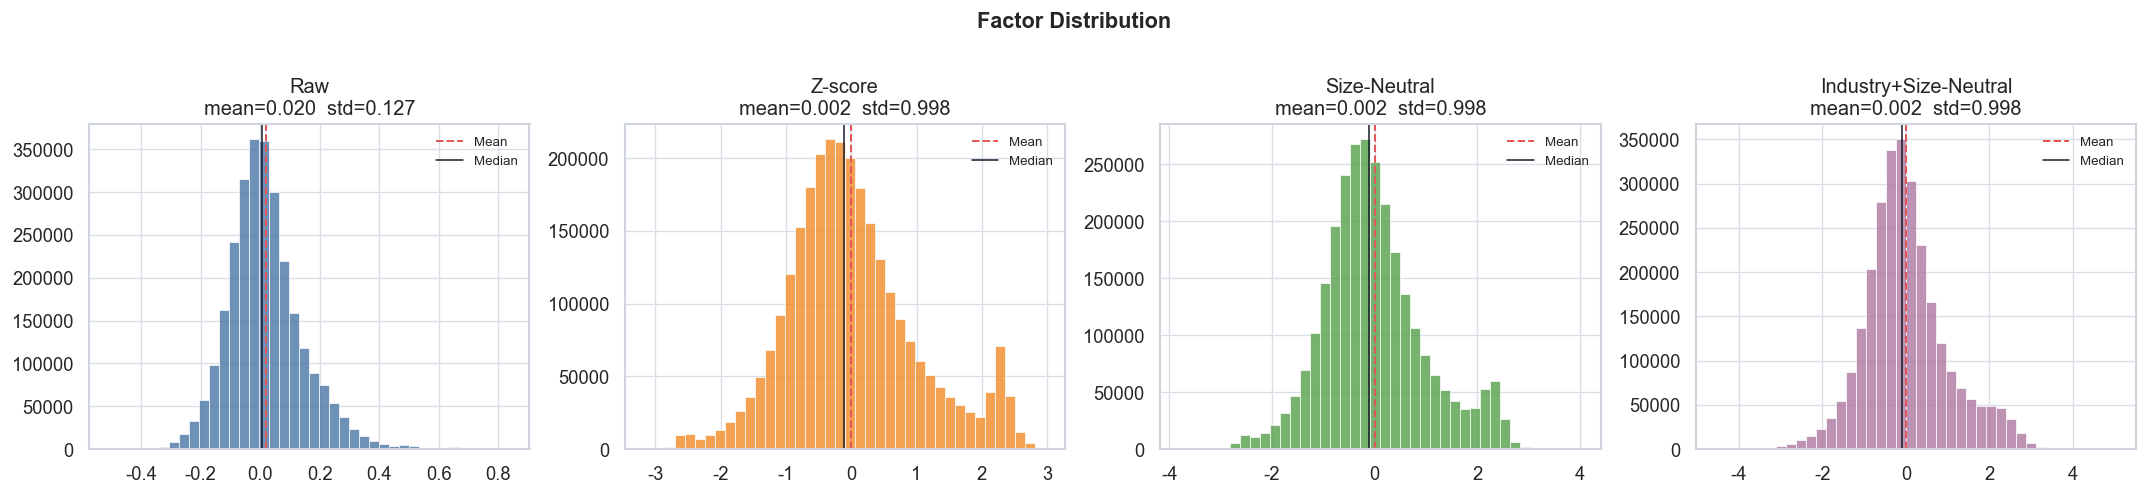

,count,mean,std,skew,p01,p99
version,,,,,,
Raw,2786505,0.0199,0.1274,0.8820,-0.2407,0.4012
Z-score,2786505,0.0022,0.9978,0.4615,-2.2692,2.4446
Size-Neutral,2786505,0.0021,0.9981,0.4651,-2.2629,2.4884
Industry+Size-Neutral,2785020,0.0022,0.9977,0.4650,-2.2955,2.6435


In [4]:
sample = df[df.universe]
labels = ["Raw", "Z-score", "Size-Neutral", "Industry+Size-Neutral"]
cols = ["factor_raw", "factor_zscore", SIZE_FACTOR_COL, FACTOR_COL]
plot_colors = [COLORS["blue"], COLORS["orange"], COLORS["green"], COLORS["purple"]]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, label, clr in zip(axes, cols, labels, plot_colors):
    vals = sample[col].dropna()
    ax.hist(vals, bins=40, color=clr, alpha=0.82, edgecolor="white", linewidth=0.5)
    ax.axvline(vals.mean(), color=COLORS["red"], linestyle="--", linewidth=1.2, label="Mean")
    ax.axvline(vals.median(), color="#111827", linestyle="-", linewidth=0.9, label="Median")
    ax.set_title(f"{label}\nmean={vals.mean():.3f}  std={vals.std():.3f}")
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("Factor Distribution", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

stats = []
for col, label in zip(cols, labels):
    v = sample[col].dropna()
    stats.append({"version": label, "count": len(v), "mean": v.mean(), "std": v.std(),
                  "skew": v.skew(), "p01": v.quantile(0.01), "p99": v.quantile(0.99)})
display(pd.DataFrame(stats).set_index("version"))


---
## Step 2. IC 分析

IC 衡量的是：今天因子排序高的股票，未来收益排序是不是也更靠前。这里使用 Rank IC，因为单因子研究通常更关心“排序能力”，而不是线性拟合得多漂亮。

## 这组图回答什么

- 📌 `Rank IC - Daily`：每日排序相关性；橙线是 20 日滚动均值。
- 📌 `Cumulative IC`：每日 IC 的累计值，曲线持续向上代表信号更稳定。
- 📌 `IC Distribution`：每日 IC 大多落在哪个区间。
- 📌 `Mean IC by Horizon`：比较 1 日、5 日、20 日未来收益哪个周期更适合。
- 📌 `IC Decay`：看 1 到 20 日的预测力如何衰减，帮助判断调仓频率。

## 新手怎么看好坏

- ✅ 平均 IC 为正：说明高因子股票未来收益排序整体更靠前。
- ✅ 正 IC 天数超过一半：说明不是少数几天偶然贡献。
- ✅ IC 衰减较慢：说明信号可能支持更长持有周期。
- ⚠️ IC 衰减很快：说明调仓周期要更谨慎，不能随便拉长。


,mean_ic,std_ic,ic_ir,win_rate,n_days
horizon,,,,,
1d,-0.0360,0.1005,-0.3578,0.3430,519
5d,-0.0493,0.0960,-0.5139,0.2755,519
20d,-0.0508,0.0931,-0.5452,0.2852,519


IC IR (fwd_5d, overlapping): -0.514
IC IR (fwd_5d, independent every 5 days): -0.463


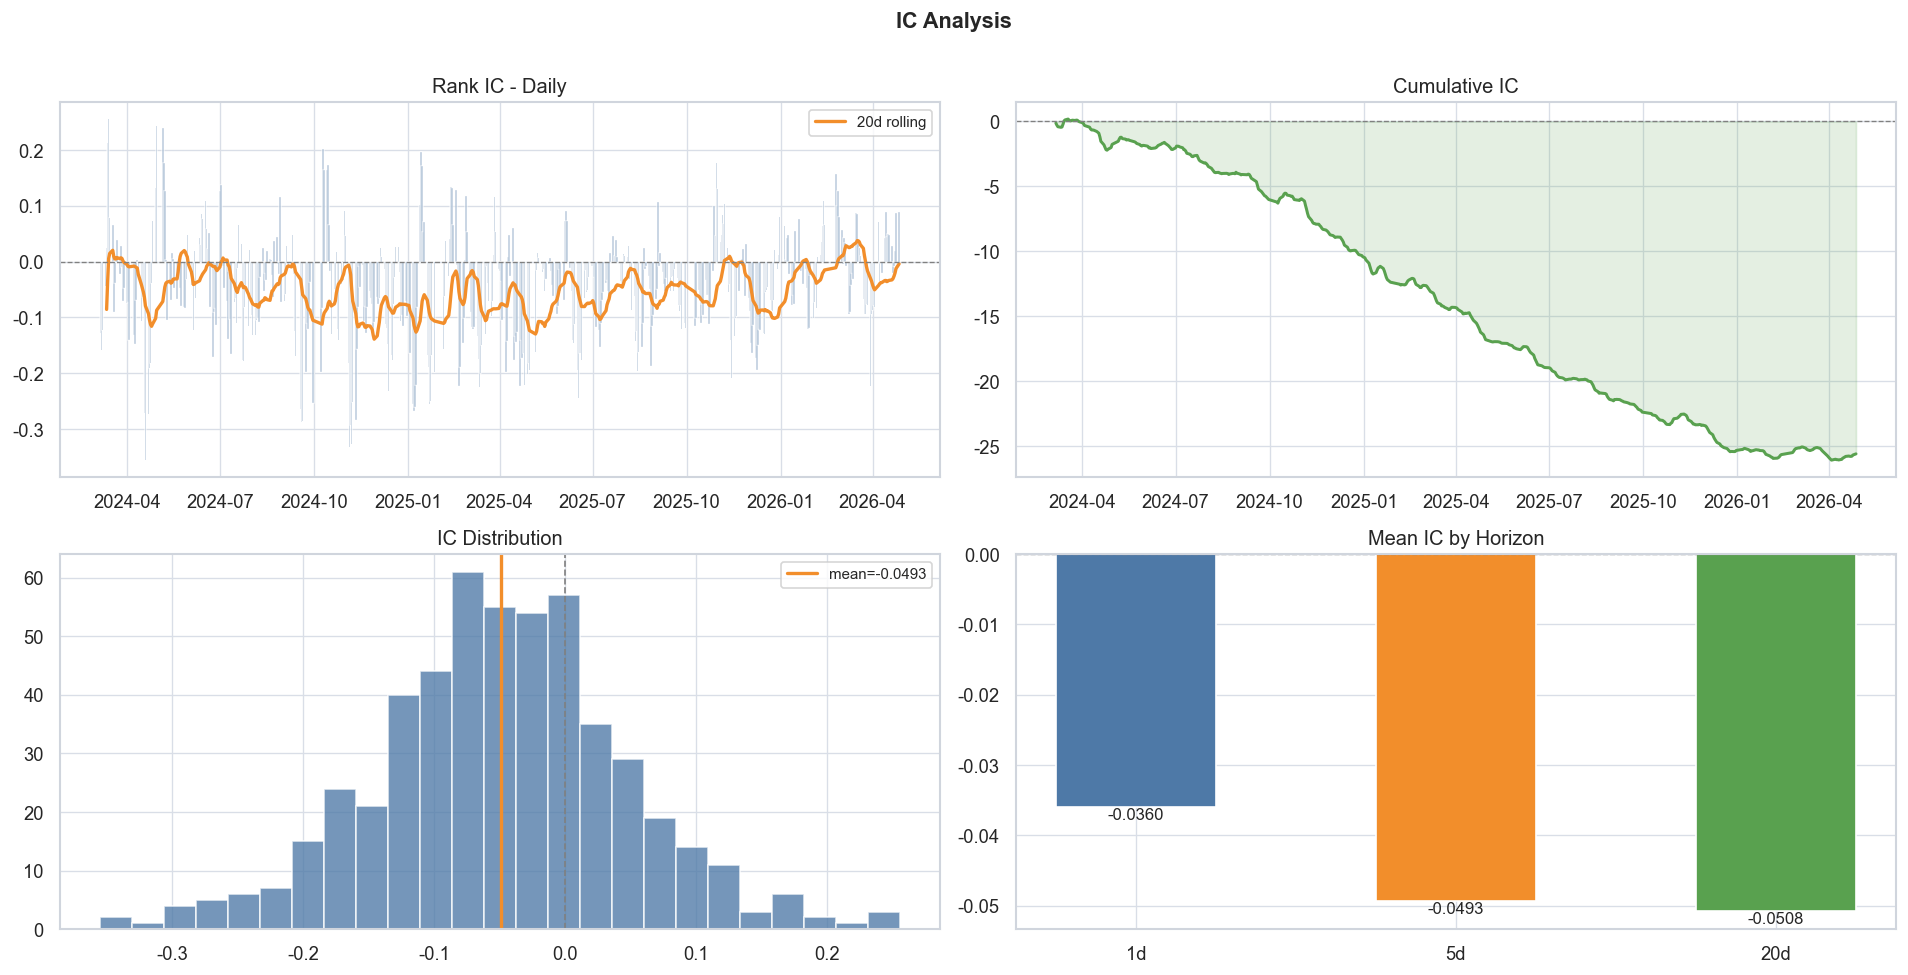

,mean_ic,std_ic,ic_ir
horizon,,,
1,-0.0360,0.1005,-0.3578
2,-0.0420,0.0985,-0.4262
3,-0.0457,0.0965,-0.4733
4,-0.0480,0.0961,-0.5000
5,-0.0493,0.0960,-0.5139
6,-0.0497,0.0959,-0.5185
7,-0.0505,0.0951,-0.5315
8,-0.0512,0.0933,-0.5493
9,-0.0518,0.0924,-0.5605


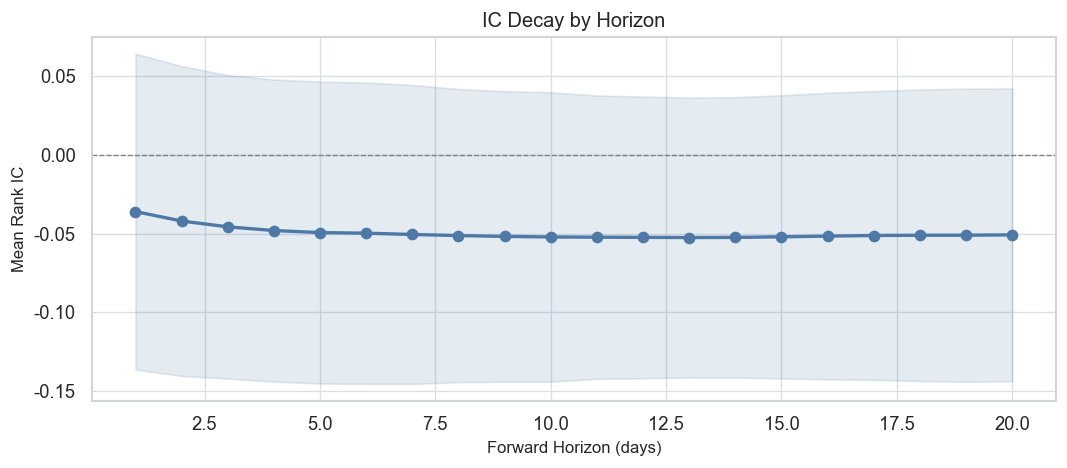

In [5]:
# Compute Rank IC for selected horizons.
research_sample = df[df.universe]
ic_frames = {}
for h in FORWARD_HORIZONS:
    ic_frames[h] = compute_rank_ic(research_sample, FACTOR_COL, f"fwd_{h}d")

ic_df = ic_frames[5]  # Main horizon.
ic_df["cum_ic"] = ic_df["rank_ic"].cumsum()
ic_df["rolling_20"] = ic_df["rank_ic"].rolling(20, min_periods=5).mean()

# Summary table.
ic_stats = []
for h in FORWARD_HORIZONS:
    ic = ic_frames[h]["rank_ic"].dropna()
    ic_stats.append({
        "horizon": f"{h}d", "mean_ic": ic.mean(), "std_ic": ic.std(ddof=0),
        "ic_ir": ic.mean() / ic.std(ddof=0) if ic.std(ddof=0) > 0 else np.nan,
        "win_rate": (ic > 0).mean(), "n_days": len(ic)
    })
display(pd.DataFrame(ic_stats).set_index("horizon"))

ic_ind = ic_df.iloc[::REBALANCE_STEP]["rank_ic"].dropna()
ic_ir_overlap = ic_df["rank_ic"].mean() / ic_df["rank_ic"].std(ddof=0) if ic_df["rank_ic"].std(ddof=0) > 0 else np.nan
ic_ir_ind = ic_ind.mean() / ic_ind.std(ddof=0) if ic_ind.std(ddof=0) > 0 else np.nan
print(f"IC IR ({FWD_COL}, overlapping): {ic_ir_overlap:.3f}")
print(f"IC IR ({FWD_COL}, independent every {REBALANCE_STEP} days): {ic_ir_ind:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

ax = axes[0, 0]
ax.bar(ic_df["trade_date"], ic_df["rank_ic"], color=COLORS["blue"], alpha=0.55, width=1.5)
ax.plot(ic_df["trade_date"], ic_df["rolling_20"], color=COLORS["orange"], linewidth=2, label="20d rolling")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Rank IC - Daily")
ax.legend()

ax = axes[0, 1]
ax.plot(ic_df["trade_date"], ic_df["cum_ic"], color=COLORS["green"], linewidth=1.8)
ax.fill_between(ic_df["trade_date"], 0, ic_df["cum_ic"], color=COLORS["green"], alpha=0.16)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Cumulative IC")

ax = axes[1, 0]
ax.hist(ic_df["rank_ic"], bins=25, color=COLORS["blue"], alpha=0.78, edgecolor="white")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(ic_df["rank_ic"].mean(), color=COLORS["orange"], linewidth=2,
           label=f'mean={ic_df["rank_ic"].mean():.4f}')
ax.set_title("IC Distribution")
ax.legend()

ax = axes[1, 1]
x = np.arange(len(FORWARD_HORIZONS))
means = [ic_frames[h]["rank_ic"].mean() for h in FORWARD_HORIZONS]
bars = ax.bar(x, means, color=HORIZON_COLORS, width=0.5)
ax.bar_label(bars, fmt="%.4f")
ax.set_xticks(x)
ax.set_xticklabels([f"{h}d" for h in FORWARD_HORIZONS])
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Mean IC by Horizon")

fig.suptitle("IC Analysis", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# IC decay: IC(t, t+h) for h=1..N.
decay_df = compute_ic_decay(research_sample, FACTOR_COL, max_lag=IC_DECAY_MAX_HORIZON)
display(decay_df.set_index("horizon"))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(decay_df["horizon"], decay_df["mean_ic"], color=COLORS["blue"], linewidth=2, marker="o")
ax.fill_between(
    decay_df["horizon"],
    decay_df["mean_ic"] - decay_df["std_ic"],
    decay_df["mean_ic"] + decay_df["std_ic"],
    color=COLORS["blue"],
    alpha=0.15,
)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("IC Decay by Horizon")
ax.set_xlabel("Forward Horizon (days)")
ax.set_ylabel("Mean Rank IC")
plt.tight_layout()
plt.show()


---
## Step 3. 分层收益

这一步对应单因子检测里的“经济含义验证”。IC 告诉我们排序相关性，分层收益告诉我们这个排序能不能转成更直观的收益差。

做法是：每天把股票按因子值分成 5 组，然后看每组未来收益。

- Q1：因子最低的一组。
- Q5：因子最高的一组。
- 如果因子方向是正的，我们希望 Q5 的未来收益高于 Q1。

## 这组图回答什么

- 📌 它回答：因子分数越高，未来收益是否越高。
- 👀 左图 `Mean Return by Quantile`：每根柱子是一组股票的平均未来收益。
- 👀 右图 `Cumulative Return by Quantile`：每组收益随时间累积后的曲线。
- ✅ 最理想形态：Q1、Q2、Q3、Q4、Q5 从低到高大体递增，右图里 Q5 长期跑在 Q1 上方。

## 新手怎么看好坏

- ✅ 单调上升最重要：不是只要求 Q5 高，而是希望从低分到高分逐步变好。
- ✅ Q5 和 Q1 差距越清楚，说明因子把好股票和差股票分得越开。
- ⚠️ 如果中间组乱序，说明因子有方向，但排序质量不够细腻。
- ⚠️ 如果只有 Q5 很高、其他组没规律，可能只是头部股票贡献，稳定性要打折。

## 当前样例怎么读

当前样例里，高分组整体更好，说明动量因子的正方向是存在的。但评分卡里会进一步检查 Q1 到 Q5 是否严格单调；如果不严格单调，就代表这个因子的排序能力还不够完美，需要后续用真实数据、行业中性化、交易成本等继续验证。


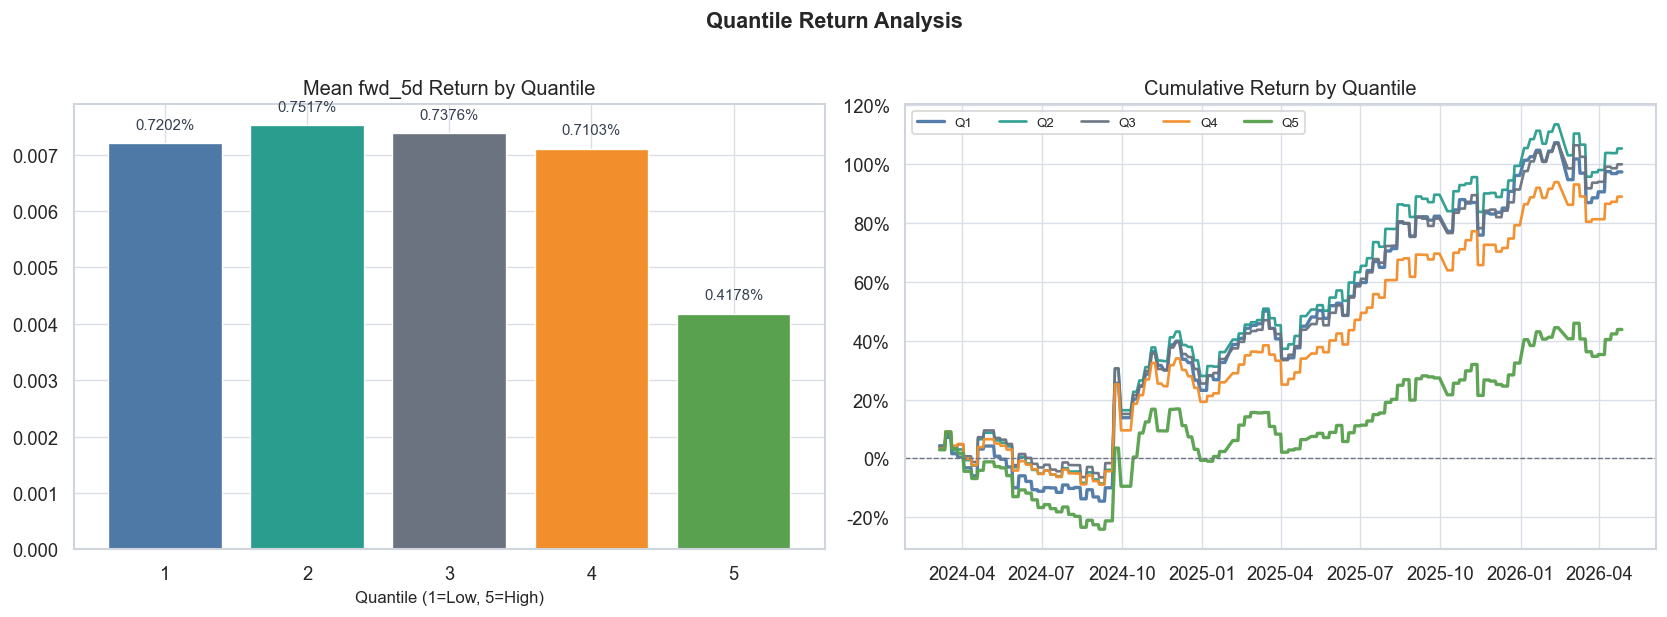

,mean_return,std_return,count,hit_rate
quantile,,,,
1,0.0072,0.0430,519,0.5684
2,0.0075,0.0393,519,0.6050
3,0.0074,0.0376,519,0.6012
4,0.0071,0.0377,519,0.5973
5,0.0042,0.0429,519,0.5530


In [6]:
# Parameters
valid = df[df.universe & df["quantile"].notna() & df[FWD_COL].notna()]
q_summary, daily_q, q_pivot = compute_quantile_returns(valid, FWD_COL)
q_summary = q_summary.set_index("quantile")
q_cum = rebalance_cumulative_returns(q_pivot, step=REBALANCE_STEP)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(q_summary.index.astype(str), q_summary["mean_return"],
              color=QUANTILE_COLORS, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, q_summary["mean_return"]):
    offset = 0.0002 if val >= 0 else -0.0002
    va = "bottom" if val >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width()/2, val + offset,
            f"{val:.4%}", ha="center", va=va, fontsize=9, color="#374151")
ax.axhline(0, color=COLORS["gray"], linestyle="--", linewidth=0.8)
ax.set_title(f"Mean {FWD_COL} Return by Quantile")
ax.set_xlabel("Quantile (1=Low, 5=High)")

ax = axes[1]
for q in range(1, N_QUANTILES + 1):
    if q in q_cum.columns:
        ax.plot(q_cum.index, q_cum[q], color=QUANTILE_COLORS[q - 1],
                linewidth=2.0 if q in (1, N_QUANTILES) else 1.6,
                alpha=0.96, label=f"Q{q}")
ax.axhline(0, color=COLORS["gray"], linestyle="--", linewidth=0.8)
ax.set_title("Cumulative Return by Quantile")
ax.legend(ncol=5, fontsize=8, frameon=True)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle("Quantile Return Analysis", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

display(q_summary)


---
## Step 4. 多空收益

这一步对应单因子检测里的“把分层结果压缩成一个最容易比较的指标”。

最常见的做法就是 `Q5 - Q1`：买最高分组，卖最低分组，观察两者之间的收益差。它不是为了马上实盘交易，而是为了快速判断“高分股相对低分股到底有没有优势”。

## 这组图回答什么

- 📌 它回答：高分组相对低分组的收益差是否稳定为正。
- 👀 左图 `Daily Spread`：每天 Q5 收益减 Q1 收益。柱子在 0 上方代表当天高分组赢了低分组。
- 👀 右图 `Cumulative Spread`：把每日 spread 累加。曲线向上代表长期高分组持续跑赢低分组。

## 新手怎么看好坏

- ✅ 日度 spread 平均值为正：说明高分组整体占优。
- ✅ 累计 spread 越平滑向上越好：说明优势不是少数几天贡献的。
- ⚠️ 如果累计曲线大起大落，说明虽然最终赚钱，但过程很不稳定。
- ⚠️ 如果分层收益看起来不错，但 Q5-Q1 很弱，说明因子方向存在，但强度不够。

## 当前样例怎么读

当前样例里，Q5-Q1 的平均 spread 和累计 spread 都是正的，所以从研究结论层面看，这个因子能把高低分股票拉开差距。但交易落地还不能直接下结论，因为这里还没有加入交易成本、冲击成本、涨跌停、停牌和融券限制。


,value
metric,
mean_spread,-0.0030
volatility,0.0179
win_rate,0.4316
cum_return,-0.2936
max_drawdown,-0.3577
sharpe,-0.1689


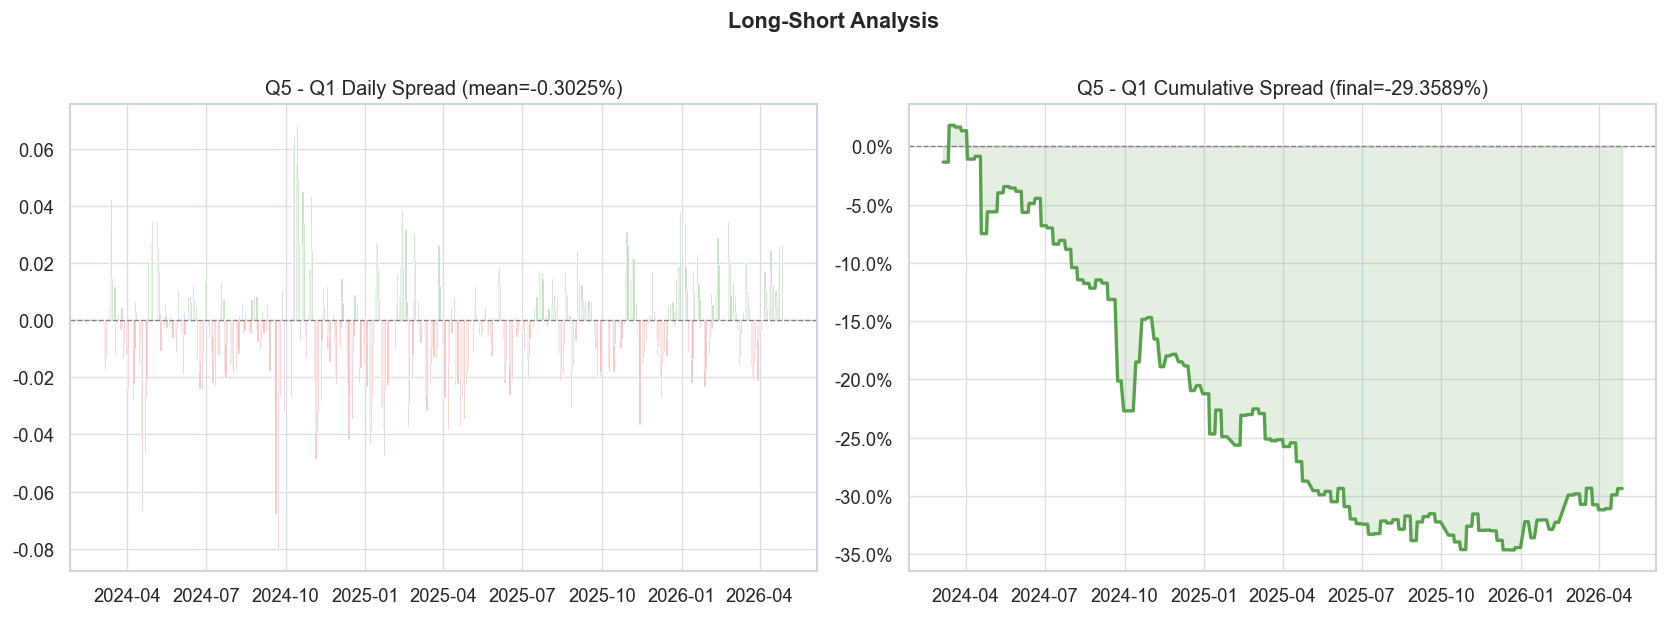

In [7]:
# Charts.
ls = long_short_spread(q_pivot, step=REBALANCE_STEP)

# Summary.
s = ls["spread"].dropna()
ls_perf = ls_summary(ls)
ls_stats = pd.DataFrame({
    "metric": ["mean_spread", "volatility", "win_rate", "cum_return", "max_drawdown", "sharpe"],
    "value": [s.mean(), s.std(), (s > 0).mean(),
              ls_perf["cum_return"], ls_perf["max_dd"],
              s.mean() / s.std() if s.std() > 0 else np.nan]
})
display(ls_stats.set_index("metric"))

# Summary. ?? ??
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(ls["trade_date"], ls["spread"],
       color=[COLORS["green"] if v >= 0 else COLORS["red"] for v in s], alpha=0.6, width=1.5)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title(f"Q5 - Q1 Daily Spread (mean={s.mean():.4%})")

ax = axes[1]
ax.plot(ls["trade_date"], ls["cum_spread"], color=COLORS["green"], linewidth=2)
ax.fill_between(ls["trade_date"], 0, ls["cum_spread"], color=COLORS["green"], alpha=0.16)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title(f'Q5 - Q1 Cumulative Spread (final={ls["cum_spread"].iloc[-1]:.4%})')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle("Long-Short Analysis", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## Step 5. 稳定性检查

这一步对应单因子检测里的“不要只看均值，要看这个因子是不是经得起时间和调仓”。

一个因子可能平均有效，但如果只在前半段有效、排序每天乱跳、换手特别高，实盘价值就会明显下降。

## 这组图回答什么

- 📌 它回答：因子是不是稳定、可持续、可调仓。
- 👀 `20-Day Rolling IC`：看 IC 的短期趋势。橙线持续在 0 上方更好。
- 👀 `Factor Rank Autocorrelation`：看今天和昨天的因子排序像不像。越接近 1，说明排序越稳定。
- 👀 `Quantile Turnover`：看每个分组每天换掉多少股票。越高，代表调仓越频繁。

## 新手怎么看好坏

- ✅ 滚动 IC 长期为正：说明预测力不是只出现在某一小段时间。
- ✅ 秩自相关较高：说明股票排序不乱跳，组合更容易维护。
- ✅ 换手率不过高：说明交易成本更容易控制。
- ⚠️ 秩自相关太低，代表每天选出来的股票变化很大，策略会很难落地。
- ⚠️ 换手率太高，即使纸面收益不错，也可能被交易成本吃掉。

## 当前样例怎么读

当前样例里，排序自相关较高，说明因子排序比较稳定；换手率不是零，说明组合会发生正常调整。结合前后半段 IC 对比，如果前后表现差异不大，就可以说这个因子在样例数据里不是“一阵风式”的偶然有效。


,n,mean_ic,win_rate,ic_ir
period,,,,
Full sample,519,-0.0493,0.2755,-0.5134
First half,259,-0.0553,0.2780,-0.4999
Second half,260,-0.0434,0.2731,-0.5509


,value
metric,
mean_autocorr,0.9219
mean_turnover,0.3057


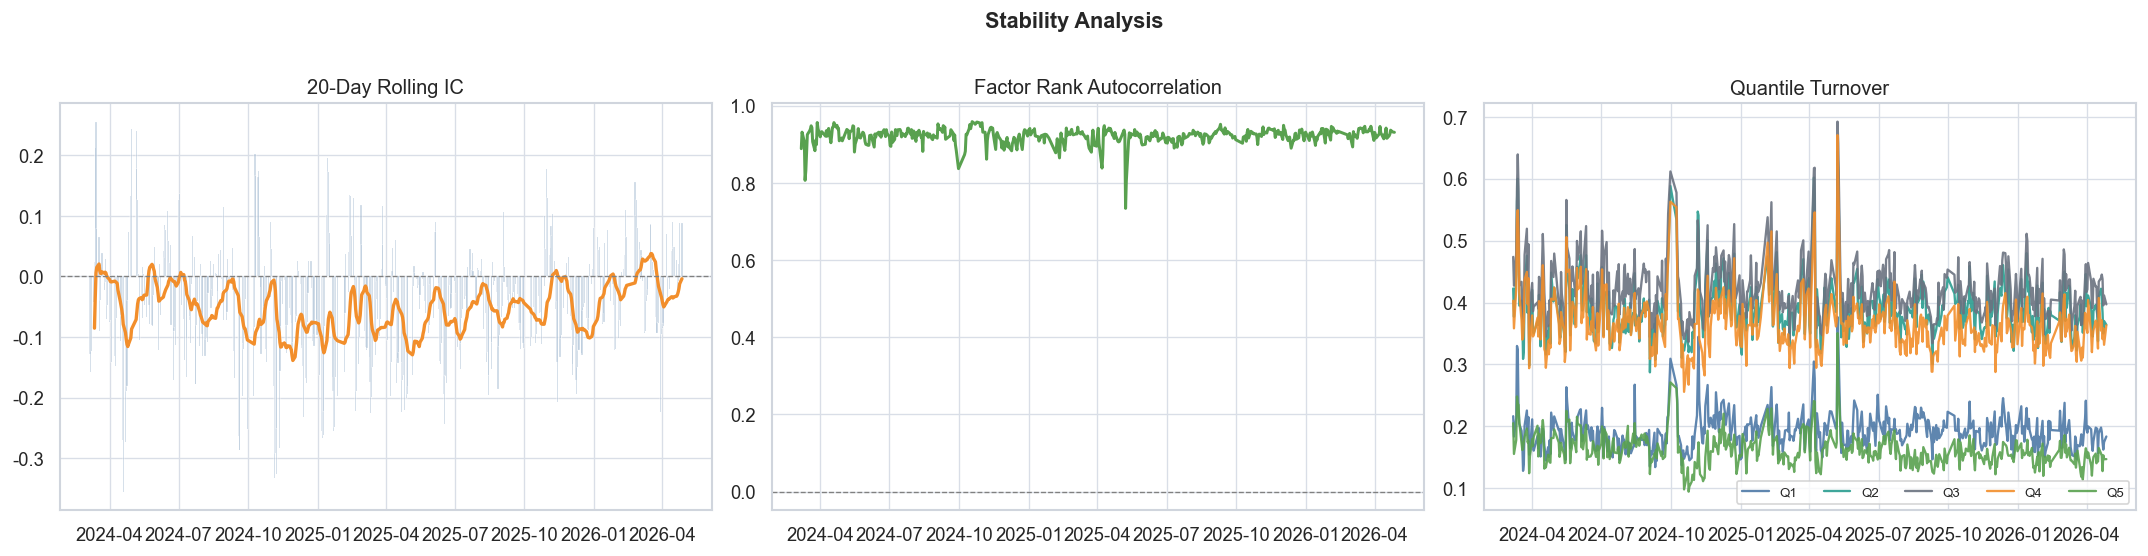

In [8]:
# 1) Compare IC between first and second halves.
mid = len(ic_df) // 2
half_stats = []
for label, part in [("Full sample", ic_df), ("First half", ic_df.iloc[:mid]), ("Second half", ic_df.iloc[mid:])]:
    ic = part["rank_ic"].dropna()
    half_stats.append({
        "period": label, "n": len(ic), "mean_ic": ic.mean(),
        "win_rate": (ic > 0).mean(),
        "ic_ir": ic.mean() / ic.std() if ic.std() > 0 else np.nan
    })
half_df = pd.DataFrame(half_stats)
display(half_df.set_index("period"))

# 2) Factor rank autocorrelation.
autocorr_df = factor_autocorr(df[df.universe], FACTOR_COL)

# 3) Quantile turnover.
dates = sorted(df[df.universe & df["quantile"].notna()]["trade_date"].unique())
turnover_rows = []
for d1, d2 in zip(dates[:-1], dates[1:]):
    prev = df[(df.trade_date == d1) & df["quantile"].notna()]
    curr = df[(df.trade_date == d2) & df["quantile"].notna()]
    for q in range(1, N_QUANTILES + 1):
        p_set = set(prev[prev["quantile"] == q]["ts_code"])
        c_set = set(curr[curr["quantile"] == q]["ts_code"])
        if len(c_set) > 0:
            turnover_rows.append({"trade_date": d2, "quantile": q,
                                  "turnover": 1 - len(p_set & c_set) / len(c_set)})
turnover_df = pd.DataFrame(turnover_rows)
t_summary = turnover_df.groupby("quantile")["turnover"].mean().reset_index()
t_summary.columns = ["quantile", "avg_turnover"]

# Summary.
display(pd.DataFrame({
    "metric": ["mean_autocorr", "mean_turnover"],
    "value": [autocorr_df["autocorr"].mean(), turnover_df["turnover"].mean()]
}).set_index("metric"))

# Summary. ?? ??
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

ax = axes[0]
ax.bar(ic_df["trade_date"], ic_df["rank_ic"], color=COLORS["blue"], alpha=0.35, width=1.5)
ax.plot(ic_df["trade_date"], ic_df["rolling_20"], color=COLORS["orange"], linewidth=2)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("20-Day Rolling IC")

ax = axes[1]
ax.plot(autocorr_df["trade_date"], autocorr_df["autocorr"], color=COLORS["green"], linewidth=1.8)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Factor Rank Autocorrelation")

ax = axes[2]
for q in range(1, N_QUANTILES + 1):
    part = turnover_df[turnover_df["quantile"] == q]
    ax.plot(part["trade_date"], part["turnover"], color=QUANTILE_COLORS[q - 1], linewidth=1.4, alpha=0.9, label=f"Q{q}")
ax.set_title("Quantile Turnover")
ax.legend(ncol=5, fontsize=8)

fig.suptitle("Stability Analysis", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## Step 6. 评分卡与研究结论

这一步把 IC、分层收益、多空收益、稳定性和换手放在一起看。目标不是过度解读某一个数字，而是判断这个因子值不值得继续研究。

## 评分卡回答什么

- 📌 `Mean IC`：平均预测方向。
- 📌 `IC Win Rate`：IC 为正的日期占比。
- 📌 `IC IR`：平均 IC / IC 波动。
- 📌 `Q1 -> Q5 Monotonic`：分层收益是否从低分组到高分组逐步改善。
- 📌 `Q5 - Q1 Mean Spread`：高分组相对低分组的平均优势。
- 📌 `Neutralization Compare`：行业+市值中性化和仅市值中性化的结论是否一致。
- 📌 `Rank Autocorr`：因子排序稳定性。
- 📌 `Avg Turnover`：调仓换手压力。

## 常见判断顺序

1. 先看 `Mean IC` 和 `IC IR`，确认有没有基础预测力。
2. 再看分层单调性，确认排序关系是否清楚。
3. 再看 `Q5 - Q1`，确认高低分差异能不能转成收益差。
4. 对比行业+市值中性化和仅市值中性化，判断是否只是行业暴露。
5. 最后看稳定性和换手，判断有没有继续策略化研究的价值。

## 当前研究口径

- ✅ 主因子使用行业+市值联合中性化，尽量避免只是在买热门行业或市值风格。
- ✅ 评分卡保留仅市值中性化版本作为对比。
- ⚠️ 如果两种中性化结论差异很大，说明行业暴露对原始动量信号影响较强，需要谨慎解释。


In [9]:
# Scorecard
ic_mean = ic_df["rank_ic"].mean()
ic_win = (ic_df["rank_ic"] > 0).mean()
ic_std = ic_df["rank_ic"].std(ddof=0)
ls_mean = ls["spread"].mean()
ls_cum = ls["cum_spread"].iloc[-1]
auto_mean = autocorr_df["autocorr"].mean()
turnover_mean = turnover_df["turnover"].mean()

comparison_rows = []
for version, factor_col in [("Size-neutral", SIZE_FACTOR_COL), ("Industry+size-neutral", FACTOR_COL)]:
    version_df = assign_quantiles(research_sample.copy(), factor_col, N_QUANTILES)
    version_q_summary, _, version_q_pivot = compute_quantile_returns(version_df, FWD_COL)
    version_ls = long_short_spread(version_q_pivot, step=REBALANCE_STEP)
    version_ic = compute_rank_ic(version_df, factor_col, FWD_COL)["rank_ic"].dropna()
    comparison_rows.append({
        "version": version,
        "mean_ic": version_ic.mean(),
        "q5_q1_mean_spread": version_ls["spread"].mean(),
        "q5_q1_cum_return": version_ls["cum_spread"].iloc[-1],
        "q5_mean_return": version_q_summary.loc[
            version_q_summary["quantile"].eq(N_QUANTILES), "mean_return"
        ].iloc[0],
    })
neutralization_compare = pd.DataFrame(comparison_rows).set_index("version")
display(neutralization_compare)

mean_returns = q_summary["mean_return"]
if mean_returns.is_monotonic_increasing:
    monotonic_state = "Positive monotonic"
    monotonic_judgement = "Pass"
elif mean_returns.is_monotonic_decreasing:
    monotonic_state = "Negative monotonic"
    monotonic_judgement = "Reverse"
else:
    monotonic_state = "No"
    monotonic_judgement = "Review"

scorecard = pd.DataFrame([
    ["Main factor version", "Industry + size neutral", "-"],
    ["Mean IC", f"{ic_mean:.4f}", "Pass" if ic_mean > 0 else "Weak"],
    ["IC Win Rate", f"{ic_win:.1%}", "Pass" if ic_win > 0.5 else "Weak"],
    ["IC IR", f"{ic_mean / ic_std:.3f}" if ic_std > 0 else "nan", "-"],
    ["IC IR (independent)", f"{ic_ir_ind:.3f}" if not np.isnan(ic_ir_ind) else "nan", "Compare"],
    ["Q1 to Q5 monotonic", monotonic_state, monotonic_judgement],
    ["Q5 - Q1 mean spread", f"{ls_mean:.4%}", "Pass" if ls_mean > 0 else "Weak"],
    ["Long-short cumulative", f"{ls_cum:.4%}", "Pass" if ls_cum > 0 else "Weak"],
    ["Size-only Mean IC", f"{neutralization_compare.loc['Size-neutral', 'mean_ic']:.4f}", "Compare"],
    ["Size-only Q5-Q1", f"{neutralization_compare.loc['Size-neutral', 'q5_q1_mean_spread']:.4%}", "Compare"],
    ["Rank autocorr", f"{auto_mean:.3f}", "-"],
    ["Avg turnover", f"{turnover_mean:.1%}", "-"],
], columns=["Metric", "Value", "Judgement"])

def scorecard_row_style(row):
    base = "color: #111827; border-color: #E5E7EB;"
    if row["Judgement"] == "Pass":
        bg = "background-color: #D1FAE5;"
    elif row["Judgement"] == "Weak":
        bg = "background-color: #FEE2E2;"
    elif row["Judgement"] == "Reverse":
        bg = "background-color: #DBEAFE;"
    elif row["Judgement"] == "Review":
        bg = "background-color: #FEF3C7;"
    elif row["Judgement"] == "Compare":
        bg = "background-color: #E0F2FE;"
    else:
        bg = "background-color: #F8FAFC;"
    return [bg + base for _ in row]

scorecard_style = (
    scorecard.style
    .apply(scorecard_row_style, axis=1)
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#111827"), ("color", "#F9FAFB"), ("border-color", "#374151")]},
        {"selector": "td", "props": [("font-weight", "500"), ("border-color", "#E5E7EB")]},
    ])
    .hide(axis="index")
)
display(scorecard_style)

print(f"Sample: {df.trade_date.nunique()} trade dates x {df.ts_code.nunique()} stocks"
      f" | valid rows {df.universe.sum():,}"
      f" | factor mom_{FACTOR_WINDOW}d"
      f" | main factor column: {FACTOR_COL} | forward return column: {FWD_COL}")


,mean_ic,q5_q1_mean_spread,q5_q1_cum_return,q5_mean_return
version,,,,
Size-neutral,-0.0597,-0.0034,-0.2944,0.0038
Industry+size-neutral,-0.0493,-0.0030,-0.2940,0.0042


Metric,Value,Judgement
Main factor version,Industry + size neutral,-
Mean IC,-0.0493,Weak
IC Win Rate,27.6%,Weak
IC IR,-0.514,-
IC IR (independent),-0.463,Compare
Q1 to Q5 monotonic,No,Review
Q5 - Q1 mean spread,-0.3025%,Weak
Long-short cumulative,-29.3589%,Weak
Size-only Mean IC,-0.0597,Compare
Size-only Q5-Q1,-0.3449%,Compare


Sample: 580 trade dates x 5611 stocks | valid rows 2,786,505 | factor mom_20d | main factor column: factor_industry_size_neutral | forward return column: fwd_5d


---
## Step 7. 轻量研究型回测

这不是生产级交易回测，而是把前面的 Q5 高分组转换成一个轻量组合视图。目的只是看：信号在加入基础调仓成本后，是否还大致站得住。

## 这里使用的简化规则

- 组合：只做多 Q5。
- 权重：对比 Q5 内部等权和市值加权。
- 调仓：每 5 个交易日调仓一次。
- 收益口径：沿用前面构造的复权收盘价未来收益标签；信号在 T 日收盘后形成，收益从 T+1 开始计算。
- 成本：使用固定双边调仓成本，公式是 `2 * turnover * one_way_cost`。
- 涨停过滤：如果 `daily_panel` 有次日开盘涨停信息，就剔除次日开盘无法买入的股票；否则保持轻量研究口径，不强行模拟真实成交。


,Metric,Value,Judgement
0,Rebalances,104,-
1,Avg holdings,1061.5,-
2,Avg period return,0.3357%,Pass
3,Cumulative net return,26.8617%,Pass
4,Annual return,12.2214%,-
5,Annual volatility,33.9605%,-
6,Simple Sharpe,0.360,-
7,Max drawdown,-31.5062%,-
8,Avg turnover,38.6%,-
9,Avg two-sided cost,0.0771%,-


,final_equity,cum_return,max_drawdown
weighting,,,
Equal Weight,1.2686,0.2686,-0.3151
Market-Cap Weight,1.5913,0.5913,-0.1788


,ew_cum_return,vw_cum_return,ew_max_drawdown,vw_max_drawdown
one_way_cost,,,,
0.0000,0.3743,0.7236,-0.3019,-0.1631
0.0010,0.2686,0.5913,-0.3151,-0.1788
0.0030,0.0807,0.3561,-0.3407,-0.2093


Limit-up filter enabled: removed Q5 names whose next open is at the up-limit price.


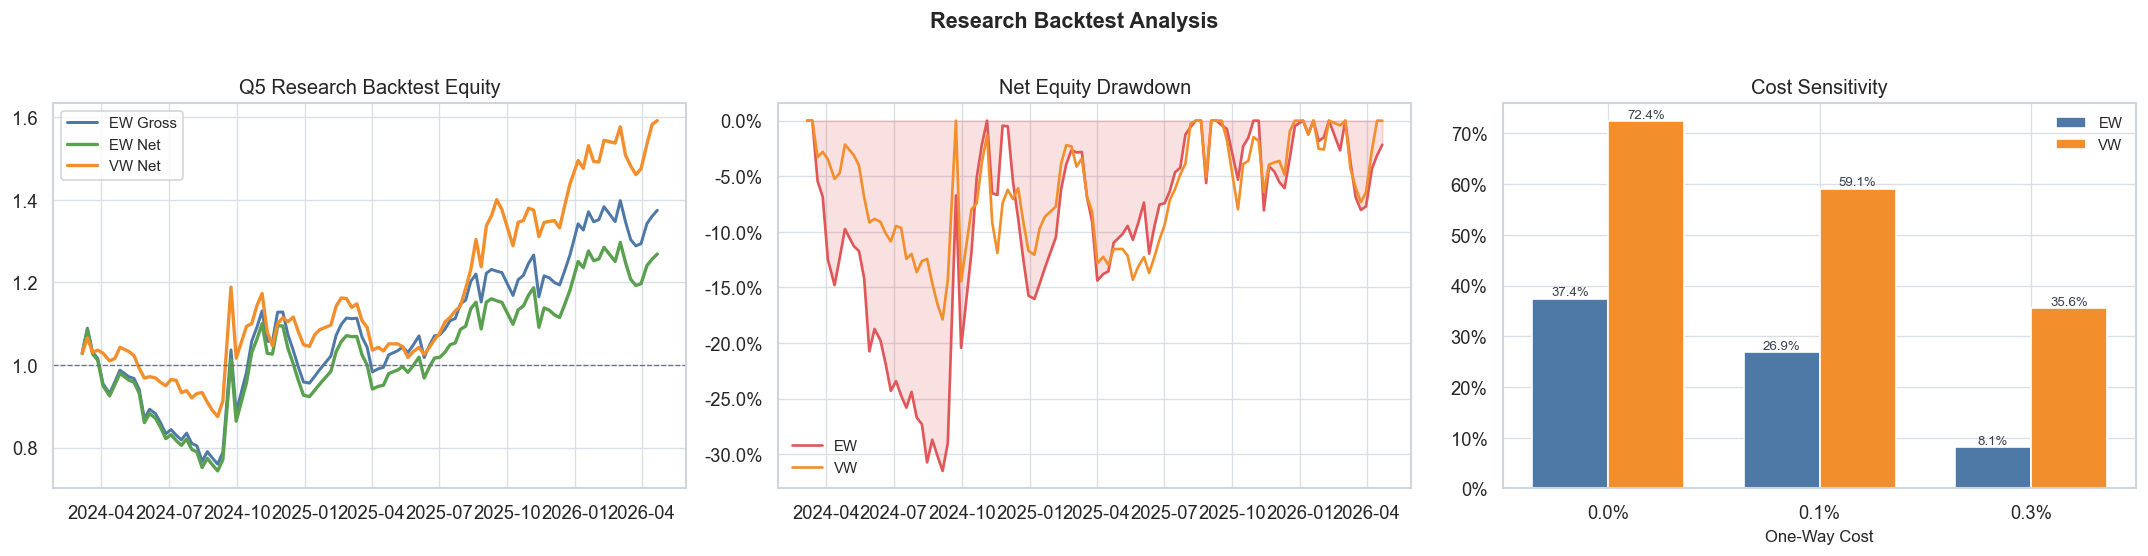

In [10]:
# Light research backtest: Q5 equal-weight and market-cap-weight portfolios, 5-day rebalance, two-sided cost.
ONE_WAY_COST = 0.001
COST_SCENARIOS = [0.0, 0.001, 0.003]
LIMIT_FILTER_COL = "next_open_is_limit_up"


def _market_cap_weighted_return(selected):
    weights = selected["total_mv"] / selected["total_mv"].sum()
    return selected[FWD_COL].mul(weights).sum()


def run_research_backtest(df, quantile=N_QUANTILES, step=REBALANCE_STEP, one_way_cost=ONE_WAY_COST):
    source = df[df.universe & df["quantile"].eq(quantile) & df[FWD_COL].notna()].copy()
    rebalance_dates = sorted(source["trade_date"].unique())[::step]
    has_limit_filter = LIMIT_FILTER_COL in source.columns

    rows = []
    prev_names = set()
    for trade_date in rebalance_dates:
        candidates = source[source["trade_date"].eq(trade_date)]
        if has_limit_filter:
            selected = candidates[~candidates[LIMIT_FILTER_COL].fillna(False)]
        else:
            selected = candidates
        names = set(selected["ts_code"])
        assert names, "Each rebalance date must have at least one tradable Q5 name."

        gross_ew = selected[FWD_COL].mean()
        gross_vw = _market_cap_weighted_return(selected)
        turnover = 1.0 if not prev_names else 1 - len(prev_names & names) / len(names)
        cost = 2 * turnover * one_way_cost
        rows.append({
            "trade_date": trade_date,
            "n_holdings": len(names),
            "limit_up_filtered": len(candidates) - len(selected),
            "gross_return_ew": gross_ew,
            "gross_return_vw": gross_vw,
            "turnover": turnover,
            "cost": cost,
            "net_return_ew": gross_ew - cost,
            "net_return_vw": gross_vw - cost,
        })
        prev_names = names

    result = pd.DataFrame(rows)
    result["gross_equity_ew"] = (1 + result["gross_return_ew"]).cumprod()
    result["gross_equity_vw"] = (1 + result["gross_return_vw"]).cumprod()
    result["net_equity_ew"] = (1 + result["net_return_ew"]).cumprod()
    result["net_equity_vw"] = (1 + result["net_return_vw"]).cumprod()
    result["drawdown_ew"] = result["net_equity_ew"] / result["net_equity_ew"].cummax() - 1
    result["drawdown_vw"] = result["net_equity_vw"] / result["net_equity_vw"].cummax() - 1
    return result


def summarize_backtest(bt, return_col="net_return_ew", equity_col="net_equity_ew", drawdown_col="drawdown_ew", periods_per_year=252 / REBALANCE_STEP):
    ret = bt[return_col]
    equity = bt[equity_col]
    annual_return = equity.iloc[-1] ** (periods_per_year / len(bt)) - 1
    annual_vol = ret.std() * np.sqrt(periods_per_year)
    return pd.DataFrame([
        ["Rebalances", f"{len(bt):,}", "-"],
        ["Avg holdings", f'{bt["n_holdings"].mean():.1f}', "-"],
        ["Avg period return", f"{ret.mean():.4%}", "Pass" if ret.mean() > 0 else "Weak"],
        ["Cumulative net return", f"{equity.iloc[-1] - 1:.4%}", "Pass" if equity.iloc[-1] > 1 else "Weak"],
        ["Annual return", f"{annual_return:.4%}", "-"],
        ["Annual volatility", f"{annual_vol:.4%}", "-"],
        ["Simple Sharpe", f"{annual_return / annual_vol:.3f}" if annual_vol > 0 else "nan", "-"],
        ["Max drawdown", f'{bt[drawdown_col].min():.4%}', "-"],
        ["Avg turnover", f'{bt["turnover"].mean():.1%}', "-"],
        ["Avg two-sided cost", f'{bt["cost"].mean():.4%}', "-"],
        ["Avg limit-up filtered", f'{bt["limit_up_filtered"].mean():.1f}', "-"],
    ], columns=["Metric", "Value", "Judgement"])


bt = run_research_backtest(df)
bt_summary = summarize_backtest(bt)
display(bt_summary)

weight_compare = pd.DataFrame([
    {"weighting": "Equal Weight", "final_equity": bt["net_equity_ew"].iloc[-1],
     "cum_return": bt["net_equity_ew"].iloc[-1] - 1, "max_drawdown": bt["drawdown_ew"].min()},
    {"weighting": "Market-Cap Weight", "final_equity": bt["net_equity_vw"].iloc[-1],
     "cum_return": bt["net_equity_vw"].iloc[-1] - 1, "max_drawdown": bt["drawdown_vw"].min()},
])
display(weight_compare.set_index("weighting"))

cost_rows = []
for cost in COST_SCENARIOS:
    scenario = run_research_backtest(df, one_way_cost=cost)
    cost_rows.append({
        "one_way_cost": cost,
        "ew_cum_return": scenario["net_equity_ew"].iloc[-1] - 1,
        "vw_cum_return": scenario["net_equity_vw"].iloc[-1] - 1,
        "ew_max_drawdown": scenario["drawdown_ew"].min(),
        "vw_max_drawdown": scenario["drawdown_vw"].min(),
    })
cost_sensitivity = pd.DataFrame(cost_rows)
display(cost_sensitivity.set_index("one_way_cost"))

if LIMIT_FILTER_COL in df.columns:
    print("Limit-up filter enabled: removed Q5 names whose next open is at the up-limit price.")
else:
    print("Limit-up filter not enabled: daily_panel lacks open/up_limit-derived next-open fields.")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

ax = axes[0]
ax.plot(bt["trade_date"], bt["gross_equity_ew"], color=COLORS["blue"], linewidth=1.8, label="EW Gross")
ax.plot(bt["trade_date"], bt["net_equity_ew"], color=COLORS["green"], linewidth=2.0, label="EW Net")
ax.plot(bt["trade_date"], bt["net_equity_vw"], color=COLORS["orange"], linewidth=2.0, label="VW Net")
ax.axhline(1.0, color=COLORS["gray"], linestyle="--", linewidth=0.8)
ax.set_title("Q5 Research Backtest Equity")
ax.legend(frameon=True)

ax = axes[1]
ax.fill_between(bt["trade_date"], bt["drawdown_ew"], 0, color=COLORS["red"], alpha=0.18)
ax.plot(bt["trade_date"], bt["drawdown_ew"], color=COLORS["red"], linewidth=1.6, label="EW")
ax.plot(bt["trade_date"], bt["drawdown_vw"], color=COLORS["orange"], linewidth=1.6, label="VW")
ax.set_title("Net Equity Drawdown")
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

ax = axes[2]
labels = [f"{c:.1%}" for c in cost_sensitivity["one_way_cost"]]
x = np.arange(len(labels))
width = 0.36
bars_ew = ax.bar(x - width / 2, cost_sensitivity["ew_cum_return"], width, color=COLORS["blue"], label="EW")
bars_vw = ax.bar(x + width / 2, cost_sensitivity["vw_cum_return"], width, color=COLORS["orange"], label="VW")
for bars in (bars_ew, bars_vw):
    for bar in bars:
        val = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, val, f"{val:.1%}", ha="center",
                va="bottom" if val >= 0 else "top", fontsize=8, color="#374151")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color=COLORS["gray"], linestyle="--", linewidth=0.8)
ax.set_title("Cost Sensitivity")
ax.set_xlabel("One-Way Cost")
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle("Research Backtest Analysis", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
